In [2]:
import os
import pickle as pkl
import sys
from pathlib import Path

import patsy
import inmoose as im

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# set project root directory
_root = Path().resolve()
if (_root / "src").is_dir():
    pass  # cwd is project root
else:
    _root = _root.parent  # cwd is notebooks/
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# set output directory for results
_output_dir = _root / "results"
_output_dir.mkdir(exist_ok=True)

# Load in Data
Downloaded from https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE47363

In [3]:
# load in GSE47363 dataset from txt file
def load_data(filename):
    '''
    Loads in data from a txt file into a Pandas DataFrame.

    Parameters
    ----------
    filename : str
        File path for the dataset.
    
    Returns
    -------
    data : Pandas DataFrame
        DataFrame containing the dataset.
    '''
    filename_str = str(filename)

    if not os.path.isfile(filename):
        raise FileNotFoundError(f"Data file not found: {filename}")
    
    if "metadata" in filename_str:
        data = pd.read_csv(filename, sep="\t", skiprows=8)
    elif "non-normalized" in filename_str:
        data = pd.read_csv(filename, sep="\t", skiprows=4, index_col="ID_REF")
    else:
        raise ValueError(f"Unrecognized filename: {filename}")
    return data

# Pre-Processing for limma

#### Justification for filtering cutoff

A 95% confidence threshold (p < 0.05) was used to filter out random noise, and genes that showed at least a 2-fold difference in expression were prioritized to ensure the changes were biologically meaningful.

In [4]:
def pre_processing(data):
    '''
    Drops p-value columns and renames columns for easier indexing (important for limma design matrix).
    Log2 transforms data and filters out genes with detection p-value > 0.05 in at least 3 samples.

    Parameters
    ----------
    data : Pandas DataFrame
        Raw data loaded in from txt file (genes as rows, samples as columns).

    Returns
    -------
    exp_data : Pandas DataFrame
        Pre-processed DataFrame containing only expression values ready for limma analysis.
    
    '''

    # filter out genes with detection p-value > 0.05 in at least 3 samples
    pval_cols = [col for col in data.columns if "PVAL" in col.upper()]
    pval_data = data[pval_cols]
    keep_genes = (pval_data <= 0.05).sum(axis=1) >= 3
    data = data[keep_genes] 

    # drop p-value columns and rename columns for easier indexing (important for limma design matrix)
    exp_cols = [col for col in data.columns if "PVAL" not in col.upper()]
    exp_data = data[exp_cols].copy()

    new_names = {
    'miR-neg_rep1': 'Control_1',
    'miR-neg_rep2': 'Control_2',
    'miR-neg_rep3': 'Control_3',
    'miR-542-3p_rep1': 'Treatment_1',
    'miR-542-3p_rep2': 'Treatment_2',
    'miR-542-3p_rep3': 'Treatment_3'
    }

    exp_data.rename(columns=new_names, inplace=True)

    # log2 transform data, adding 1 to avoid log(0) issues
    exp_data = np.log2(exp_data + 1)

    return exp_data

#### Justification for deduplication strategy
For Gene IDs represented by multiple probes, the MaxMean strategy was used to select the probe with the highest average expression across all samples. This approach was taken based on the rationale that probe with the highest signal usually has the highest signal-to-noise ratio, making that probe the most reliable representative for that gene.

In [5]:
def drop_duplicates(exp_data):
    '''
    Drops duplicates, selecting the probe that has the highest average expression for each gene.

    Parameters
    ----------
    exp_data : Pandas DataFrame
        Pre-processed DataFrame containing only log-transformed expression values ready for limma analysis.

    Returns
    -------
    exp_data_clean : Pandas DataFrame
        Expression dataframe without duplicate probe IDs.
    '''

    # calculate average expression across all samples for each row
    exp_data['row_mean'] = exp_data.mean(axis=1)

    # sort dataframe by that mean in ascending order
    data_sorted = exp_data.sort_values(by='row_mean', ascending=False)

    # drop duplicates based on the index (probe ID)
    # sorted descending, so first will be highest average expression
    data_dropped = data_sorted[~data_sorted.index.duplicated(keep='first')]

    # remove row_mean helper column so it doesn't interfere with limma
    exp_data_clean = data_dropped.drop(columns=['row_mean'])

    return exp_data_clean

# Design Matrix Creation

In [6]:
def build_design_matrix(exp_data):
    '''
    Builds design matrix for limma analysis based on the experimental conditions. 
    Calculates mean expression for each group and creates a design matrix with one-hot encoding for Control vs Treatment.

    Parameters
    ----------
    exp_data : Pandas DataFrame
        Cleaned and log2 transformed DataFrame (genes as rows, samples as columns).

    Returns
    -------
    patsy_design : Patsy DesignMatrix object
        Patsy design matrix for limma analysis.
    '''

    sample_names = exp_data.columns

    # infer groups based on names
    groups = ['Control' if 'control' in s.lower() else 'Treatment' for s in sample_names]

    # create design matrix using one-hot encoding
    design_matrix = pd.get_dummies(groups).astype(int)
    design_matrix.index = sample_names

    # convert to patsy DesignMatrix
    patsy_design = patsy.DesignMatrix(design_matrix)

    return patsy_design

# Build Contrast Matrix

In [7]:
def build_constrast_matrix(patsy_design_mat):
    '''
    Builds contrast matrix for limma analysis based on the patsy design matrix.
    Tells limma to subtract mean expression of Control group from mean expression of Treatment group to get log fold change for each gene.

    Parameters
    ----------
    patsy_design : Patsy DesignMatrix object
        Patsy design matrix for limma analysis.

    Returns
    -------
    contrast_matrix : Pandas DataFrame
        Contrast matrix for limma analysis.
    '''
    # get column names patsy is using
    groups = patsy_design_mat.design_info.column_names
    
    # create contrast matrix using those names as the index
    contrast_matrix = pd.DataFrame(index=groups)

    # Control is alphabetically first (column0) and Treatment is second (column1)
    # want Treatment (column1) - Control (column0)
    contrast_matrix['Treatment_vs_Control'] = 0.0
    contrast_matrix.loc['column0', 'Treatment_vs_Control'] = -1.0
    contrast_matrix.loc['column1', 'Treatment_vs_Control'] = 1.0

    return contrast_matrix

# Perform Analysis Using InMoose

#### Rationale for using limma (through InMoose library) as the DE method
Limma uses Empirical Bayes moderation to shrink gene-wise variability toward a common trend. This is especially important for small datasets like this one because it increases statistical power and reduces the likelihood that low-variance outliers drive false positives. It's also the standard library used for differential expression analysis of microarray data.

#### Rationale for using Benjamini-Hochberg (BH) method for multiple testing correction
Multiple testing correction was performed using the Benjamini-Hochberg algorithm within the topTable function to control the False Discovery Rate (FDR) at 5%.

In [8]:
def analyze_data(exp_data, patsy_design_mat, contrast_matrix):
    '''
    Runs limma analysis on the pre-processed data using the design and contrast matrices.
    Runs the full pipeline: lm_fit, contrasts_fit, and e_bayes.
    By default, returns results for the first contrast.

    Parameters
    ----------
    exp_data : Pandas DataFrame
        Pre-processed DataFrame containing only expression values ready for limma analysis.

    patsy_design : Patsy DesignMatrix object
        Patsy design matrix for limma analysis.

    contrast_matrix : Pandas DataFrame
        Contrast matrix for limma analysis.

    Returns
    -------
    results : Pandas DataFrame
        DataFrame containing limma results with log fold changes, p-values, and adjusted p-values for each gene.
    '''

    # fit linear model to data  
    fit = im.limma.lmFit(exp_data, patsy_design_mat)

    # apply contrasts to fitted model
    fit2 = im.limma.contrasts_fit(fit, contrast_matrix)

    # compute empirical Bayes statistics
    fit2 = im.limma.eBayes(fit2)

    # extract results for the first contrast (Treatment vs Control)
    results = im.limma.topTable(fit2, coef="Treatment_vs_Control", number=np.inf) # uses Benjamini-Hochberg method

    # sort by adjusted p-value
    results = results.sort_values(by='adj_pvalue')
    
    return results


# Map Probe ID to Gene Name Using GPL10558 Annotation Table

In [9]:
def map_probes_to_genes(results_df, annotation_file):
    """
    Merges gene symbols into the limma results table.

    Parameters
    ----------
    results_df : Pandas DataFrame
        Dataframe containing the results of the limma DE analysis.

    annotation_file: str
        File path to the GPL10558 annotation file.

    Returns
    -------
    final_results : Pandas DataFrame
        Results of limma analysis with probe ID mapped to gene name.

    """

    filename_str = str(annotation_file)

    if not os.path.isfile(filename_str):
        raise FileNotFoundError(f"Data file not found: {filename_str}")
    
    # find header row
    skip_rows = 0
    with open(annotation_file, 'r') as f:
        for i, line in enumerate(f):
            # usually contains Symbol and Definition
            if 'Symbol' in line and 'Definition' in line:
                skip_rows = i
                break

    # load annotation file, skipping metadata
    annot = pd.read_csv(annotation_file, sep='\t', skiprows=skip_rows, low_memory=False)

    # dynamically find ID and Symbol cols
    # find ID column first
    id_col = next((c for c in annot.columns if c.upper() in ['ID', 'ID_REF', 'PROBE_ID', 'PROBE_ID']), None)
    
    # Find symbol column
    symbol_col = next((c for c in annot.columns if 'SYMBOL' in c.upper()), None)
    
    if not id_col or not symbol_col:
        raise KeyError(f"Could not find ID or Symbol columns. Found: {annot.columns.tolist()}")
        
    # map probe Id to gene name
    mapping = annot[[id_col, symbol_col]].copy()
    mapping.columns = ['ID_REF', 'Symbol']

    # convert to dataframe to prevent InMoose error
    results_pd = pd.DataFrame(results_df)

    # left merge with mapping to preserve all rows even if not matched with gene name
    final_results = results_pd.reset_index().merge(mapping, on='ID_REF', how='left')
    
    # drop rows where Symbol is missing
    final_results = final_results.dropna(subset=['Symbol'])
    
    return final_results.set_index('ID_REF')

# Create iPathway Guide Input File

In [10]:
def export_for_ipathway(results_df, filename="iPathway_upload.csv", output_path=_output_dir):
    """
    Formats and exports limma results for iPathwayGuide.

    Parameters
    ----------
    results_df : Pandas DataFrame
        Results of limma analysis, including mapping to gene name.
        Expected columns: gene_symbol, logFC, adj_pvalue

    filename : str
        Filename for the output CSV file.

    Returns
    -------
    upload_df : Pandas DataFrame
        Data saved in CSV file to be uploaded to iPathway Guide.
    """
    # select only gene_symbol, logFC, adj_pvalue columns
    upload_df = results_df[['Symbol', 'log2FoldChange', 'pvalue']].copy()
    
    # rename columns to provided names
    upload_df.columns = ['gene_symbol', 'logFC', 'adj_pvalue']
    
    # sort by p-value
    upload_df = upload_df.sort_values('adj_pvalue')
    
    # save to CSV without the row index (ID_REF)
    if output_path:
        upload_df.to_csv(output_path/filename, index=False)
    
    print(f"iPathway Guide input file saved successfully as: {filename}")
    return upload_df.head()

# Visualize Data 

In [11]:
def visualize_volcano(results_df, p_threshold=0.05, lfc_threshold=1.0, top_n=10, output_path=_output_dir):
    """
    Creates a volcano plot from limma results.
    Identifies significant up/downregulated genes and labels the top hits.

    Parameters
    ----------
    results_df : Pandas DataFrame
        Results of limma analysis, including mapping to gene name.
        Expected columns: gene_symbol, logFC, adj_pvalue

    p_threshold : float
        Value that specifies significance threshold.

    lfc_threshold : float
        Value that specifies log fold change threshold.

    top_n : int
        Value that specifies how many genes to label on the plot with gene name.

    """
    plt.figure(figsize=(10, 7))
    
    # create column for coloring points
    results_df['status'] = 'Not Significant'
    results_df.loc[(results_df['adj_pvalue'] < p_threshold) & (results_df['log2FoldChange'] > lfc_threshold), 'status'] = 'Upregulated'
    results_df.loc[(results_df['adj_pvalue'] < p_threshold) & (results_df['log2FoldChange'] < -lfc_threshold), 'status'] = 'Downregulated'

    # transform p-value to -log10 for y-axis
    results_df['-log10p'] = -np.log10(results_df['pvalue'])

    # plot points
    palette = {'Not Significant': 'grey', 'Upregulated': '#e74c3c', 'Downregulated': '#3498db'}
    sns.scatterplot(data=results_df, x='log2FoldChange', y='-log10p', 
                    hue='status', palette=palette, alpha=0.6, edgecolor=None)

    # add threshold lines
    plt.axhline(-np.log10(p_threshold), color='black', linestyle='--', alpha=0.5)
    plt.axvline(lfc_threshold, color='black', linestyle='--', alpha=0.5)
    plt.axvline(-lfc_threshold, color='black', linestyle='--', alpha=0.5)

    # label top N significant genes
    top_hits = results_df.sort_values('adj_pvalue').head(top_n)
    for i, row in top_hits.iterrows():
        plt.text(row['log2FoldChange'], row['-log10p'] + 0.2, row['Symbol'], 
                 fontsize=9, fontweight='bold', ha='center')

    # format plot
    plt.title(f'Volcano Plot: miR-542-3p Mimic vs Control', fontsize=15)
    plt.xlabel('log2 Fold Change', fontsize=12)
    plt.ylabel('-log10 (p-value)', fontsize=12)
    plt.legend(title='Gene Status')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()

    if output_path:
        save_file = output_path / "Volcano_Plot.png"
        plt.savefig(save_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_file}")
        
    plt.show()

# Validate Workflow Using Targetscan

In [12]:
def validate_with_targetscan(results_df, targetscan_file, output_path=_output_dir):
    """
    Validates results against TargetScan predictions using a CDF plot.

    Parameters
    ----------
    results_df : Pandas DataFrame
        Results of limma analysis, including mapping to gene name.
        Expected columns: gene_symbol, logFC, adj_pvalue

    targetscan_file : str
        Path to file containing TargetScan data.

    output_path : str
        Location to save CDF plot to as a PNG.
    """
    # load and clean TargetScan targets
    ts_data = pd.read_csv(targetscan_file, sep='\t')
    ts_targets = set(ts_data['Gene Symbol'].unique())
    
    # split results into targets and non-targets
    results_df['is_target'] = results_df['Symbol'].isin(ts_targets)
    
    targets_lfc = results_df[results_df['is_target']]['log2FoldChange']
    non_targets_lfc = results_df[~results_df['is_target']]['log2FoldChange']
    
    # perform Kolmogorov-Smirnov (KS) Test
    # tests if the two distributions are statistically different
    ks_stat, ks_p = stats.ks_2samp(targets_lfc, non_targets_lfc)
    
    # plot CDF
    plt.figure(figsize=(8, 6))
    
    # plot non-targets
    sns.ecdfplot(non_targets_lfc, label=f'Non-Targets (n={len(non_targets_lfc)})', color='grey')
    
    # plot TargetScan targets
    sns.ecdfplot(targets_lfc, label=f'TargetScan Targets (n={len(targets_lfc)})', color='blue')
    
    # format plot
    plt.axvline(0, color='black', linestyle='--', alpha=0.5)
    plt.title(f'Validation: miR-542-3p Target Enrichment\nKS-test p-value: {ks_p:.2e}', fontsize=14)
    plt.xlabel('log2 Fold Change', fontsize=12)
    plt.ylabel('Cumulative Fraction', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()

    if output_path:
        save_file = output_path / "miR-542-3p_TargetScan_Validation.png"
        plt.savefig(save_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_file}")

    plt.show()
    
    return ks_p

In [ ]:
def rank_miRNAs(results):
    # load Master TargetScan Mapping
    # only need the following cols: 'miR Family', 'Gene Symbol'
    mir_families = pd.read_csv(_root / "data" / 'miR_Family_Info.txt', sep='\t')
    predictions = pd.read_csv(_root / "data" / 'Predicted_Targets_Info.default_predictions.txt', sep='\t', usecols=['miR Family', 'Gene Symbol'])

    # filter for Human miRNAs only (Species ID 9606)
    human_mirs = mir_families[mir_families['Species ID'] == 9606]

    all_rankings = []

    # loop through all miRNA families
    for family, targets in predictions.groupby('miR Family'):
        # get list of predicted gene symbols for this family
        target_genes = targets['Gene Symbol'].unique()
        
        # check enrichment in results
        is_target = results['Symbol'].isin(target_genes)
        
        t_lfc = results[is_target]['log2FoldChange']
        nt_lfc = results[~is_target]['log2FoldChange']
        
        # must have at least 15 targets in dataset for a valid KS-test
        if len(t_lfc) > 15:
            _, p_val = stats.ks_2samp(t_lfc, nt_lfc, alternative='greater')
            all_rankings.append({'Family': family, 'p_value': p_val, 'n_targets': len(t_lfc)})

    # create ranking df
    rank_df = pd.DataFrame(all_rankings).sort_values('p_value')
    rank_df['Rank'] = range(1, len(rank_df) + 1)

    # check where miR-542-3p ranks (ideally at the top)
    print(rank_df.head())

# Run Analysis Pipeline and Validate Using TargetScan

In [14]:
def run_analysis_and_validate(data_filename, annotation_filename, targetscan_filename):

    # load in data
    df = load_data(data_filename)
    print(f"Loaded data shape: {df.shape}\n")

    # pre-process data
    exp_df = pre_processing(df)
    print(f"Post pre-processing data shape: {exp_df.shape}\n")

    # drop duplicates (keep highest average expression)
    exp_df_clean = drop_duplicates(exp_df)
    print(f"Data shape after duplicate removal: {exp_df_clean.shape}\n")

    # build design matrix
    patsy_design = build_design_matrix(exp_df_clean)
    print(f"Patsy design matrix: {patsy_design}\n")

    # build contrast matrix
    contrast_matrix = build_constrast_matrix(patsy_design)
    print(f"Contrast matrix: {contrast_matrix}\n")

    # run analysis using limma
    print("Analysis results:\n")
    results = analyze_data(exp_df_clean, patsy_design, contrast_matrix)
    print(f"{results.head()}\n")

    # map probe ID to gene name
    print("Analysis results with gene names:\n")
    results_with_genes = map_probes_to_genes(results, annotation_filename)
    print(results_with_genes.head())

    # create iPathway Guide input file
    export_for_ipathway(results_with_genes)

    # visualize results with volcano plot
    visualize_volcano(results_with_genes)

    # validate with TargetScan
    p_value = validate_with_targetscan(results_with_genes, targetscan_filename, _output_dir)

    # rank miRNAs by p-value
    print("miRNAs ranked by p-value:\n")
    rank_miRNAs(results_with_genes)

Loaded data shape: (47323, 12)

Post pre-processing data shape: (18113, 6)

Data shape after duplicate removal: (18113, 6)

Patsy design matrix: [[1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]

Contrast matrix:          Treatment_vs_Control
column0                  -1.0
column1                   1.0

Analysis results:

              log2FoldChange     lfcSE    AveExpr       stat        pvalue  \
ID_REF                                                                       
ILMN_1759915       -2.582207  0.816497  10.776856 -23.305564  9.847539e-14   
ILMN_2349459       -2.991616  0.816497  10.525322 -23.239538  1.029017e-13   
ILMN_1680626       -2.503895  0.816497   9.497947 -23.285820  9.977739e-14   
ILMN_1785191       -2.245509  0.816497   9.876560 -22.745482  1.435333e-13   
ILMN_3298037       -2.764447  0.816497  12.075999 -22.252570  2.014334e-13   

                adj_pvalue          B  
ID_REF                                 
ILMN_1759915  6.212859e-10  21.486651  
ILMN_

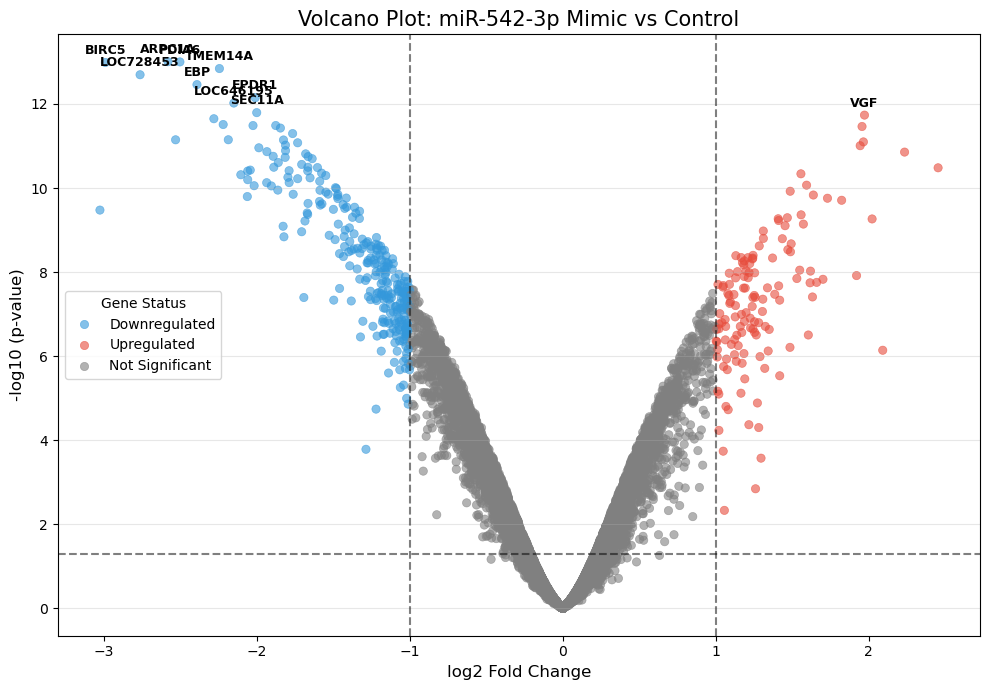

Plot saved to: /workspaces/GSE47363_analysis/results/miR-542-3p_TargetScan_Validation.png


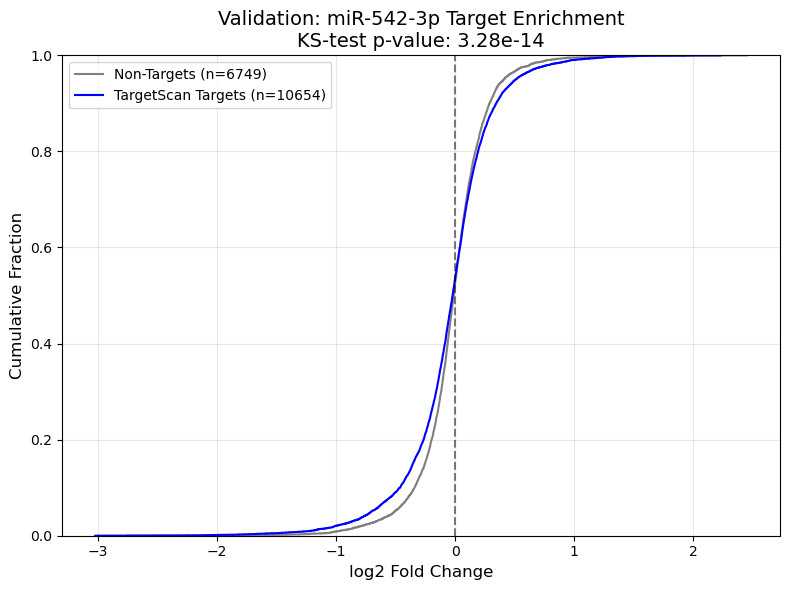

miRNAs ranked by p-value:

                Family       p_value  n_targets  Rank
502         miR-542-3p  6.355212e-21        331     1
501            miR-542  8.746150e-18        272     2
122  miR-15/16/195/497  1.879420e-07       1275     3
344         miR-34/449  5.282892e-07        749     4
343   miR-34-5p/449-5p  1.192997e-06        736     5


In [15]:
# run differential expression analysis using limma
data_filename = _root / "data" / "GSE47363_non-normalized.txt"
annotation_filename = _root / "data" / "GPL10558_annot.txt"
targetscan_filename = _root / "data" / "TargetScan_miR-542-3p.txt"
run_analysis_and_validate(data_filename, annotation_filename, targetscan_filename)

### Biological interpretation is included in the README.